<a href="https://colab.research.google.com/github/9terry-student/PyTorch/blob/main/11_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%8B%A4%EB%A3%A8%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11장 데이터 다루기

## 3. 판다스를 활용한 데이터 조사

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 깃허브에 준비된 데이터 호출
!git clone https://github.com/taehojo/data.git

# 피마 인디언 당뇨병 데이터셋 호출
df=pd.read_csv('./data/pima-indians-diabetes3.csv')

Cloning into 'data'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 36 (delta 9), reused 26 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 483.12 KiB | 4.98 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
# 처음 5줄 표시
df.head(5)

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 정상과 당뇨 환자 명수
df['diabetes'].value_counts()

,count
diabetes,
0,500
1,268


In [4]:
# 각 정보별 특징 자세히 출력
df.describe()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# 각 항목의 상관관계
df.corr()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
pregnant,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plasma,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


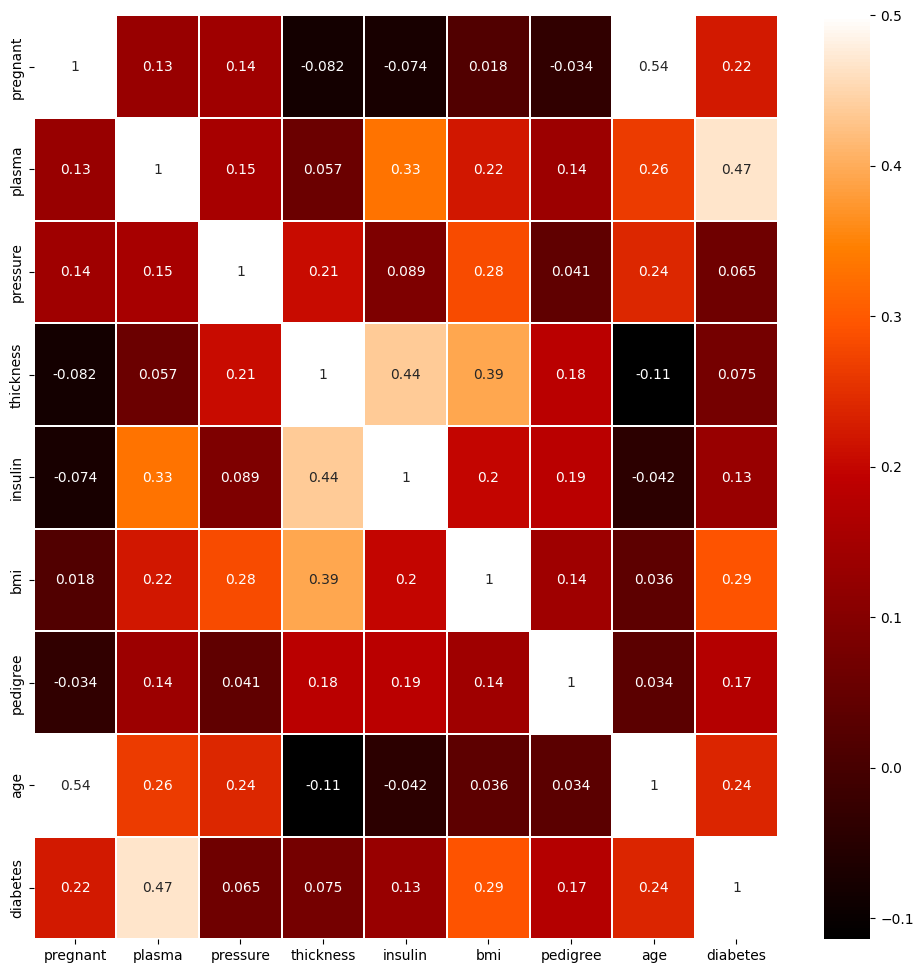

In [6]:
# 데이터 간의 상관 관계 그래프로 표현
colormap=plt.cm.gist_heat     # 그래프의 색상 구성
plt.figure(figsize=(12,12))     # 그래프의 크기

# 그래프의 속성 결정(vmax의 값을 0.5로 지정해 0.5에 가까울수록 밝은색 표시)
sns.heatmap(df.corr(),linewidths=0.1,vmax=0.5,cmap=colormap,linecolor='white',annot=True)
plt.show()

## 4. 중요한 데이터 추출하기

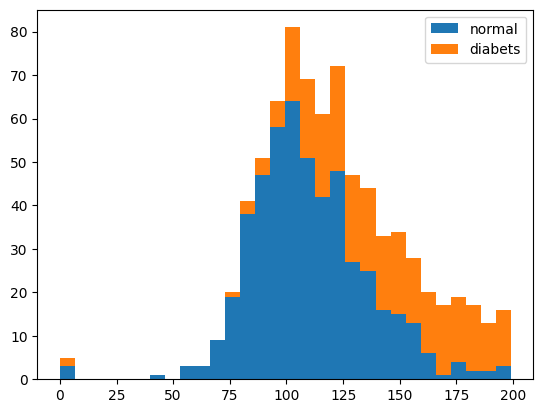

In [7]:
import warnings
warnings.filterwarnings('ignore')

# plasma를 기준으로 정상과 당뇨 비율 분포 확인
plt.hist(x=[df.plasma[df.diabetes==0],df.plasma[df.diabetes==1]],bins=30,histtype='barstacked',
         label=['normal','diabets'])
plt.legend()

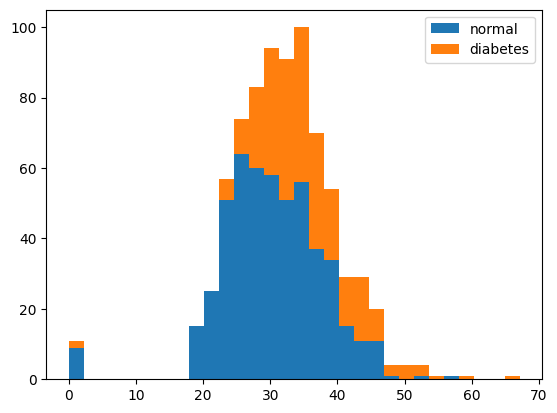

In [8]:
# BMI를 기준으로 정상과 당뇨 비율 분포 확인
plt.hist(x=[df.bmi[df.diabetes==0],df.bmi[df.diabetes==1]],bins=30,histtype='barstacked',
         label=['normal','diabetes'])
plt.legend()

## 5. 피마 인디언 당뇨병 예측 실행

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# pandas 라이브러리 호출
import pandas as pd

# 깃허브에 준비된 데이터 호출
!git clone https://github.com/taehojo/data.github
# 피마 인디언 당뇨병 데이터셋 호출
df=pd.read_csv('./data/pima-indians-diabetes3.csv')

Cloning into 'data.github'...
fatal: could not read Username for 'https://github.com': No such device or address


In [10]:
# X: 세부정보
X=df.iloc[:,0:8]
# y: 당뇨병 여부
y=df.iloc[:,8]

In [11]:
# 모델 설정
model=Sequential()
model.add(Dense(12,input_dim=8,activation='relu',name='Dense_1'))
model.add(Dense(8,activation='relu',name='Dense_2'))
model.add(Dense(1,activation='sigmoid',name='Dense_3'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 모델 컴파일
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

# 모델 실행
hisotry=model.fit(X,y,epochs=100,batch_size=5)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6003 - loss: 9.4716 
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5820 - loss: 1.8332
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6003 - loss: 1.4587
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6315 - loss: 1.2776
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6380 - loss: 1.1019
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6471 - loss: 0.9551
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6393 - loss: 0.9448
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6237 - loss: 0.8648
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6562 - loss: 0.8021
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6276 - loss: 0.7787
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6784 - loss: 0.6975
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━━━━